In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys 

import analysis_utils
sys.path.append("../")

import checkpoint

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Loaded following dataloaders:
val dataloader (n=22,912),
test dataloader (n=22,912)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:146,640
	best val loss achieved: 1.0977
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.098
Best Validation Accuracy: 0.427


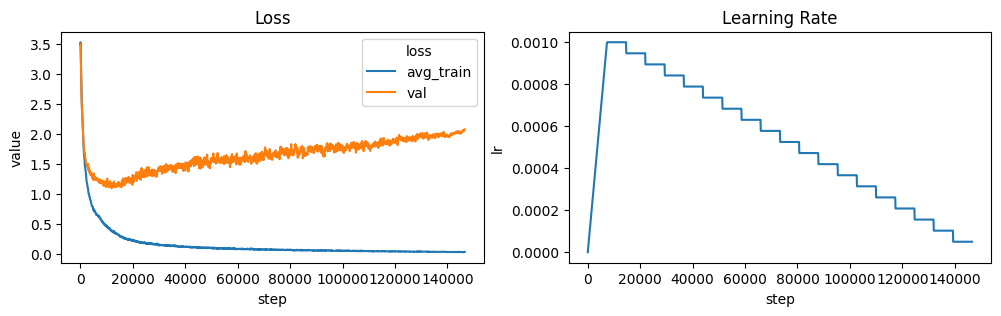

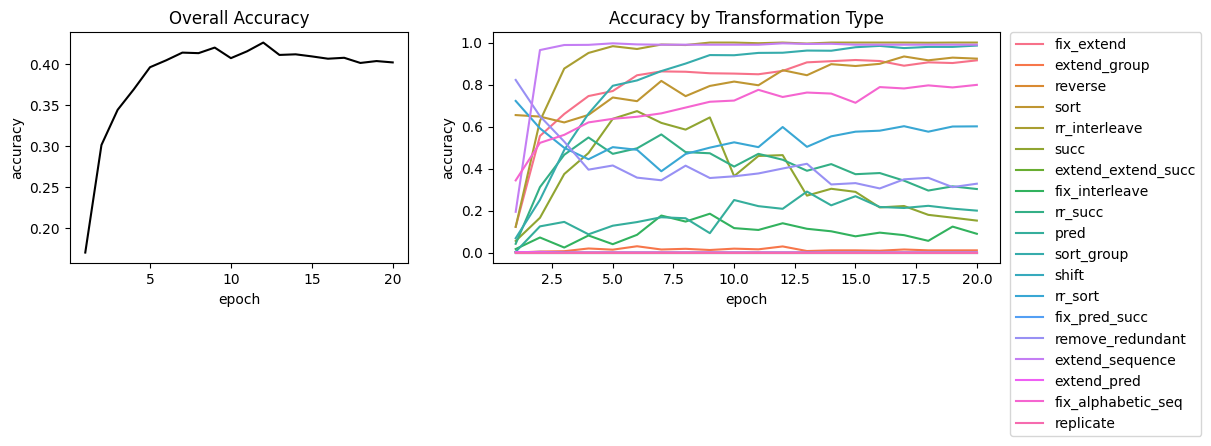

In [32]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study1", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

Loaded following dataloaders:
val dataloader (n=22,825),
test dataloader (n=22,825)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:146,080
	best val loss achieved: 1.0904
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.090
Best Validation Accuracy: 0.372


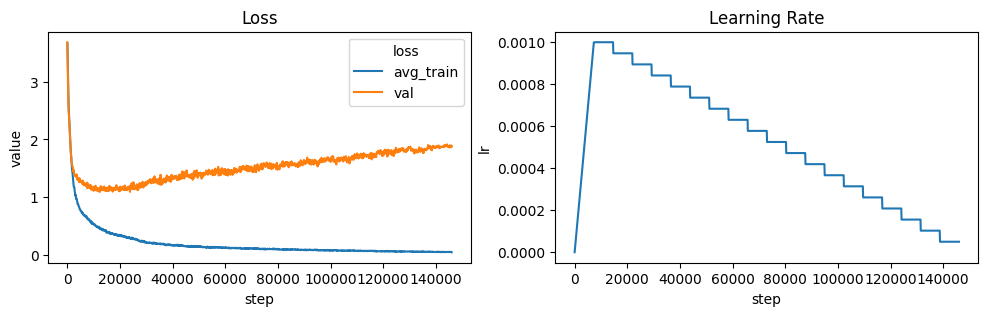

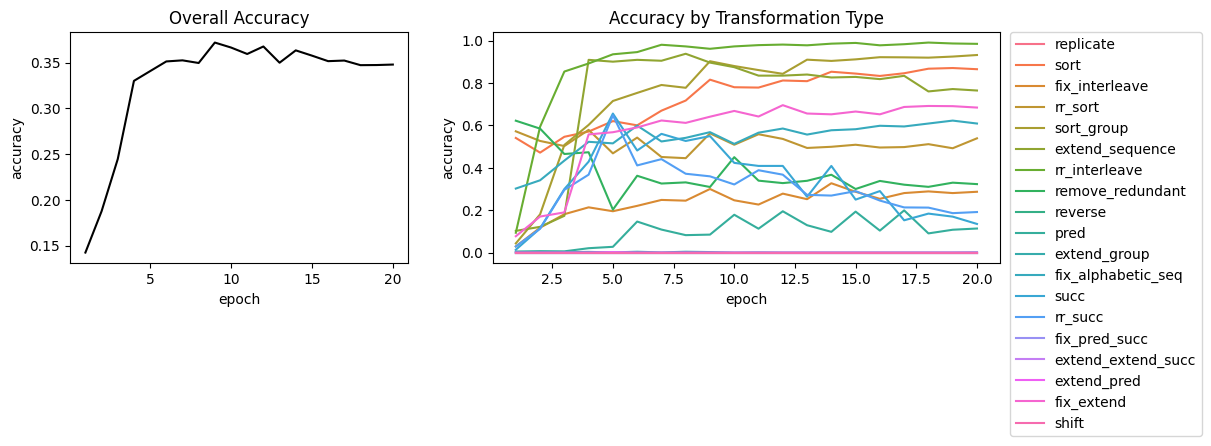

In [33]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy2_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study2", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

Loaded following dataloaders:
val dataloader (n=22,682),
test dataloader (n=22,682)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:145,180
	best val loss achieved: 1.0800
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.080
Best Validation Accuracy: 0.420


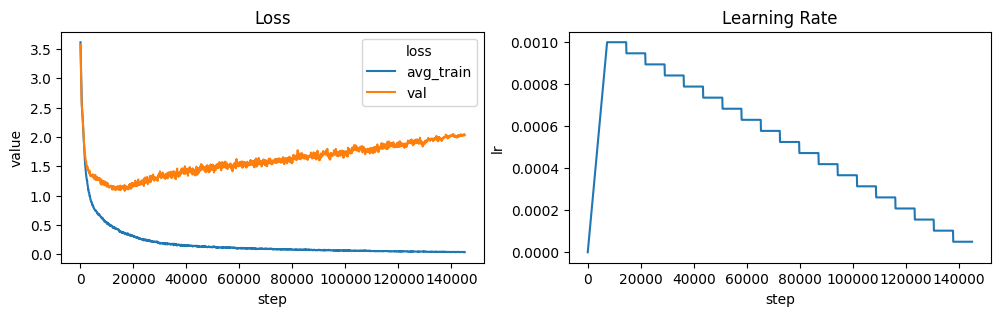

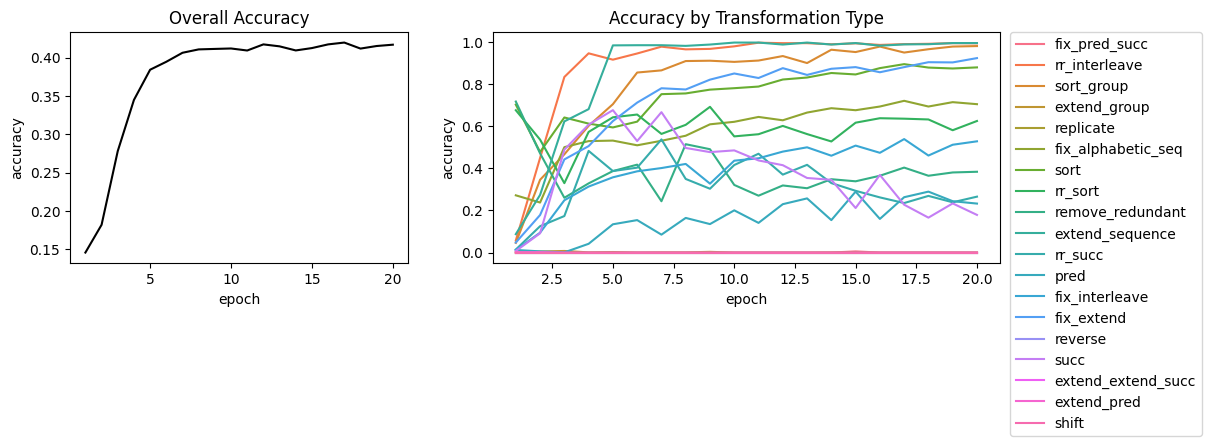

In [35]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy3_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study3", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

Loaded following dataloaders:
val dataloader (n=22,157),
test dataloader (n=22,157)
Loading model that has completed (or started) 20 of 20 epochs
	batch size: 25
	number of steps:141,820
	best val loss achieved: 1.0755
MLC specs:
	1,400,606 parameters
	3 encoder layers
	3 decoder layers
	8 attention heads
	128 embedding size
	512 feedforward layer sizes
	gelu activation function
	p=0.1 dropout
Training information for model trained with 3 study examples:
Best Validation Loss: 1.075
Best Validation Accuracy: 0.421


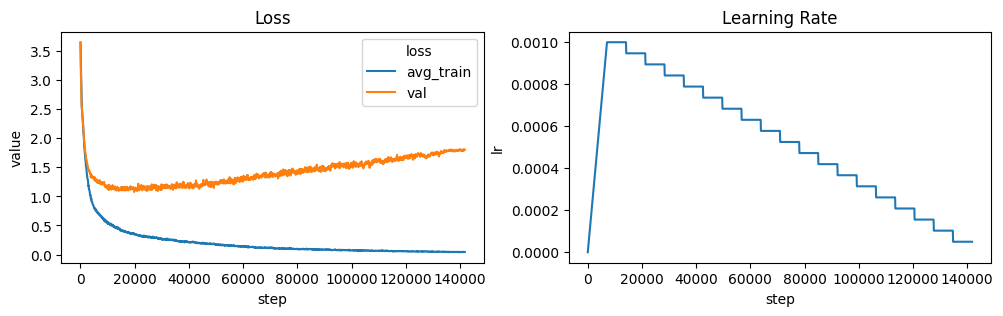

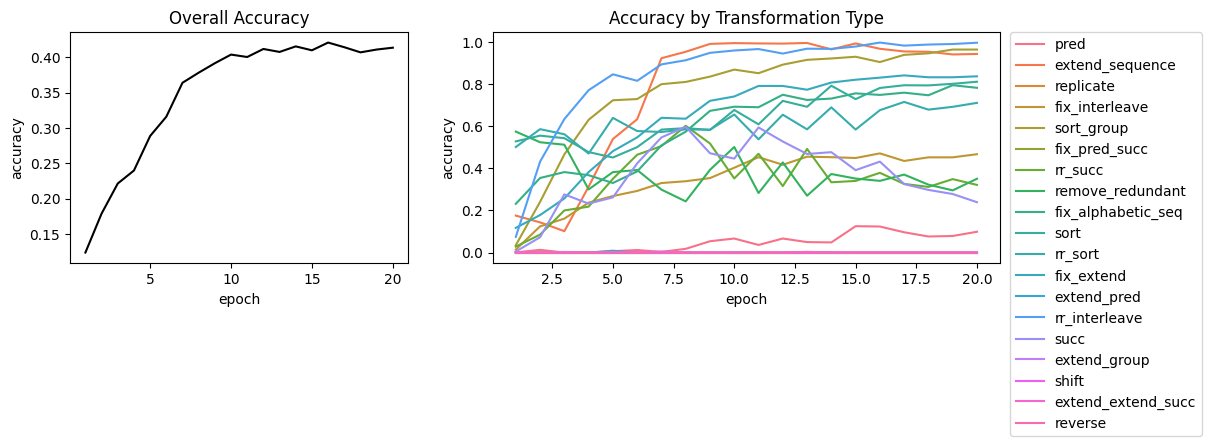

In [34]:
cp = checkpoint.CheckPoint("../models/MLC_dallstudy4_nep20.pt", device=DEVICE)
val, test = cp.load_dataloaders("../data/all_transformations_study4", val_batch_size=1000, use_datasets=["val","test"])
model = cp.load_model()
analysis_utils.training_information(cp, val, "Training information for model trained with 3 study examples:")

### Generalization types

In [ ]:
val_acc = pd.DataFrame(cp.checkpoint["val_accuracy"])
val_acc = pd.melt(val_acc, id_vars=['epoch'], value_vars=val.dataset.transformation_types, var_name="transformation", value_name="accuracy")

In [ ]:
import generate_data

generalization_types = dict()
type_0 = {trans[1].__name__: 0 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[:10]}
generalization_types.update(type_0)
type_2 = {trans[1].__name__: 2 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[10:16]}
generalization_types.update(type_2)
type_3 = {trans[1].__name__: 3 for trans in list(generate_data.ALL_TRANSFORMATIONS.items())[16:]}
generalization_types.update(type_3)
for key, value in generalization_types.items():
    print(key, value)
val_acc["generalization_type"] = val_acc["transformation"].apply(lambda x: generalization_types[x])

In [30]:
val_acc["generalization_type"] = val_acc["transformation"].apply(lambda x: generalization_types[x])

In [32]:
val_final_acc = val_acc[val_acc.epoch == val_acc.epoch.max()]

In [36]:
val_final_acc.groupby("generalization_type")["accuracy"].mean()

generalization_type
0    0.563749
2    0.138513
3    0.000000
Name: accuracy, dtype: float64

In [ ]:
#  Transformations present in both data splits
# 1.	Extend Sequence (a b c d -> a b c d e)
# 2.	Successor (a b c d -> a b c e)
# 3.	Predecessor (b c d e -> a c d e)
# 4.	Remove Redundant letter (a b b c d -> a b c d)
# 5.	Fix alphabetic sequence (a b c w e -> a b c d e)
# 6.	Sort (a d c b e -> a b c d e)
# 7.	Sort + Group (aa dd cc bb ee -> aa bb cc dd ee)
# 8.	Remove redundant + Interleave (a x b x b x c x d -> a x b x c x d)
# 9.	Remove Redundant + successor (a b b c d -> a b c e)
# 10.	Fix alphabetic sequence + extend sequence (a b c w -> a b c d e)
#
# Transformations only present in validation/ test splits:
# 11. Remove Redundant + Sort (a d d c b e -> a b c d e)
# 12. Extend Sequence + Predecessor (b c d e -> a c d e f)
# 13. Fix alphabetic sequence + Interleave (a f b f c f w f e -> a f b f c f d f e)
# 14. Extend sequence + Group (aa bb cc dd -> aa bb cc dd ee)
# 15. Extend Sequence + Extend Sequence + Successor (a b c d -> a b c d e g)
# 16. Fix alphabetic Sequence + Predecessor + Successor (a b c w e -> a a c d f)
# 17. Reverse (a b c d -> d c b a)
# 18. Shift (a b c d -> e f g h)
# 19. Replicate (a b c d -> a b c d a b c d)

In [4]:
cp_study1 = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val_acc1 = pd.DataFrame(cp_study1.checkpoint["val_accuracy"])
val_acc1

,epoch,overall,extend_extend_succ,extend_group,extend_pred,extend_sequence,fix_alphabetic_seq,fix_extend,fix_interleave,fix_pred_succ,...,remove_redundant,replicate,reverse,rr_interleave,rr_sort,rr_succ,shift,sort,sort_group,succ
0,1,0.120155,0.001099,0.000000,0.0,0.305616,0.199838,0.149361,0.012759,0.000000,...,0.463415,0.0,0.0,0.100392,0.412510,0.017210,0.0,0.479266,0.038125,0.036048
1,2,0.282472,0.000000,0.001622,0.0,0.924872,0.398050,0.369808,0.032695,0.000000,...,0.515808,0.0,0.0,0.635294,0.509105,0.347826,0.0,0.519936,0.325655,0.440587
2,3,0.301065,0.000000,0.004866,0.0,0.905908,0.464663,0.455272,0.091707,0.000000,...,0.338753,0.0,0.0,0.814902,0.391132,0.500000,0.0,0.543062,0.373312,0.461949
3,4,0.350122,0.000000,0.011354,0.0,0.913931,0.469537,0.533546,0.066188,0.000000,...,0.302620,0.0,0.0,0.919216,0.428345,0.642210,0.0,0.580542,0.658459,0.670895
4,5,0.337116,0.000000,0.005677,0.0,0.938731,0.452478,0.514377,0.091707,0.000000,...,0.348690,0.0,0.0,0.920000,0.483769,0.493659,0.0,0.546252,0.701350,0.531375
5,6,0.356756,0.000000,0.012165,0.0,0.943107,0.563769,0.555911,0.129984,0.000000,...,0.499548,0.0,0.0,0.933333,0.492478,0.374094,0.0,0.627592,0.669579,0.518024
6,7,0.378099,0.000000,0.017843,0.0,0.932896,0.546710,0.611022,0.150718,0.008354,...,0.551942,0.0,0.0,0.970196,0.574822,0.248188,0.0,0.723285,0.848292,0.534045
7,8,0.362387,0.000000,0.011354,0.0,0.913202,0.497157,0.556709,0.122010,0.000000,...,0.354110,0.0,0.0,0.980392,0.431512,0.489130,0.0,0.649123,0.868944,0.541389
8,9,0.374214,0.000000,0.007299,0.0,0.900073,0.533712,0.569489,0.196970,0.000000,...,0.329720,0.0,0.0,0.979608,0.521774,0.468297,0.0,0.685008,0.866561,0.534045
9,10,0.369981,0.000000,0.003244,0.0,0.923414,0.545085,0.592652,0.137959,0.000000,...,0.316170,0.0,0.0,0.990588,0.429929,0.554348,0.0,0.687400,0.896743,0.433912


### Comparison number of study examples

In [25]:
cp_study1 = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val_acc1 = pd.DataFrame(cp_study1.checkpoint["val_accuracy"])
val_acc1 = pd.melt(val_acc1, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc1["study_examples"] = 1

cp_study2 = checkpoint.CheckPoint("../models/MLC_dallstudy2_nep20.pt", device=DEVICE)
val_acc2 = pd.DataFrame(cp_study2.checkpoint["val_accuracy"])
val_acc2 = pd.melt(val_acc2, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc2["study_examples"] = 2

cp_study3 = checkpoint.CheckPoint("../models/MLC_dallstudy3_nep20.pt", device=DEVICE)
val_acc3 = pd.DataFrame(cp_study3.checkpoint["val_accuracy"])
val_acc3 = pd.melt(val_acc3, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc3["study_examples"] = 3

cp_study4 = checkpoint.CheckPoint("../models/MLC_dallstudy4_nep20.pt", device=DEVICE)
val_acc4 = pd.DataFrame(cp_study4.checkpoint["val_accuracy"])
val_acc4 = pd.melt(val_acc4, id_vars=['epoch'], value_vars=["in","out-of"], var_name="distribution", value_name="accuracy")
val_acc4["study_examples"] = 4

In [26]:
val_acc_by_nstudy = pd.concat([val_acc1,val_acc2,val_acc3,val_acc4])
val_acc_by_nstudy.head()

,epoch,distribution,accuracy,study_examples
0,1,in,0.233793,1
1,2,in,0.479949,1
2,3,in,0.572515,1
3,4,in,0.616659,1
4,5,in,0.664606,1


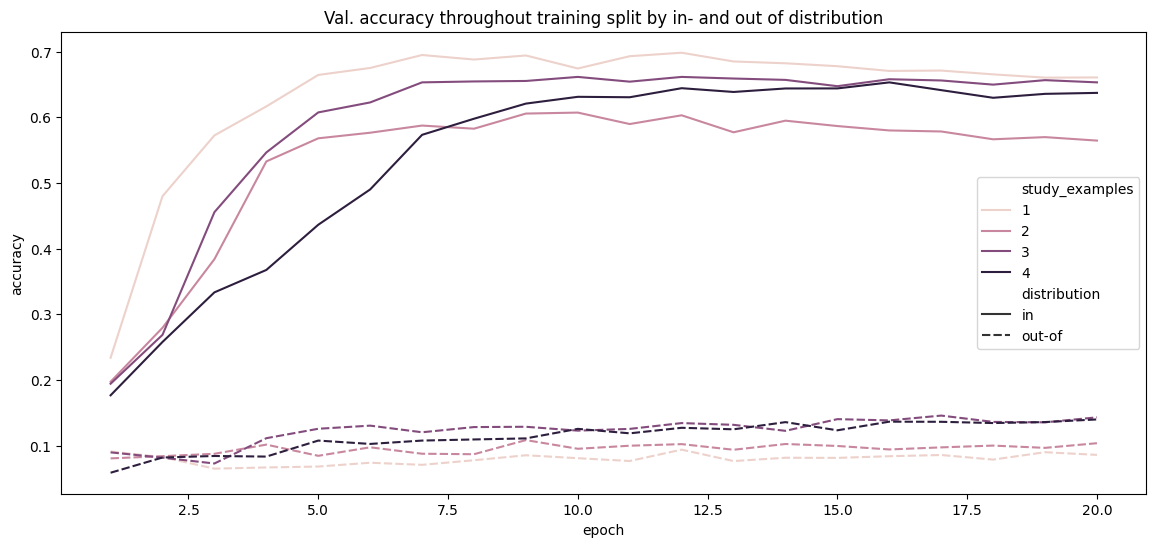

In [ ]:
fig, ax = plt.subplots(figsize=(14,6))
_ = sns.lineplot(data=val_acc_by_nstudy, x="epoch", y="accuracy", hue="study_examples", style="distribution", ax=ax)
_ = ax.set_title("Val. accuracy throughout training split by in- and out of distribution")

In [21]:
cp_study1 = checkpoint.CheckPoint("../models/MLC_dallstudy1_nep20.pt", device=DEVICE)
val_acc1 = pd.DataFrame(cp_study1.checkpoint["val_accuracy"])
val_acc1 = pd.melt(val_acc1, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc1["study_examples"] = 1

cp_study2 = checkpoint.CheckPoint("../models/MLC_dallstudy2_nep20.pt", device=DEVICE)
val_acc2 = pd.DataFrame(cp_study2.checkpoint["val_accuracy"])
val_acc2 = pd.melt(val_acc2, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc2["study_examples"] = 2

cp_study3 = checkpoint.CheckPoint("../models/MLC_dallstudy3_nep20.pt", device=DEVICE)
val_acc3 = pd.DataFrame(cp_study3.checkpoint["val_accuracy"])
val_acc3 = pd.melt(val_acc3, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc3["study_examples"] = 3

cp_study4 = checkpoint.CheckPoint("../models/MLC_dallstudy4_nep20.pt", device=DEVICE)
val_acc4 = pd.DataFrame(cp_study4.checkpoint["val_accuracy"])
val_acc4 = pd.melt(val_acc4, id_vars=['epoch'], value_vars=["overall"], var_name="overall", value_name="accuracy")
val_acc4["study_examples"] = 4

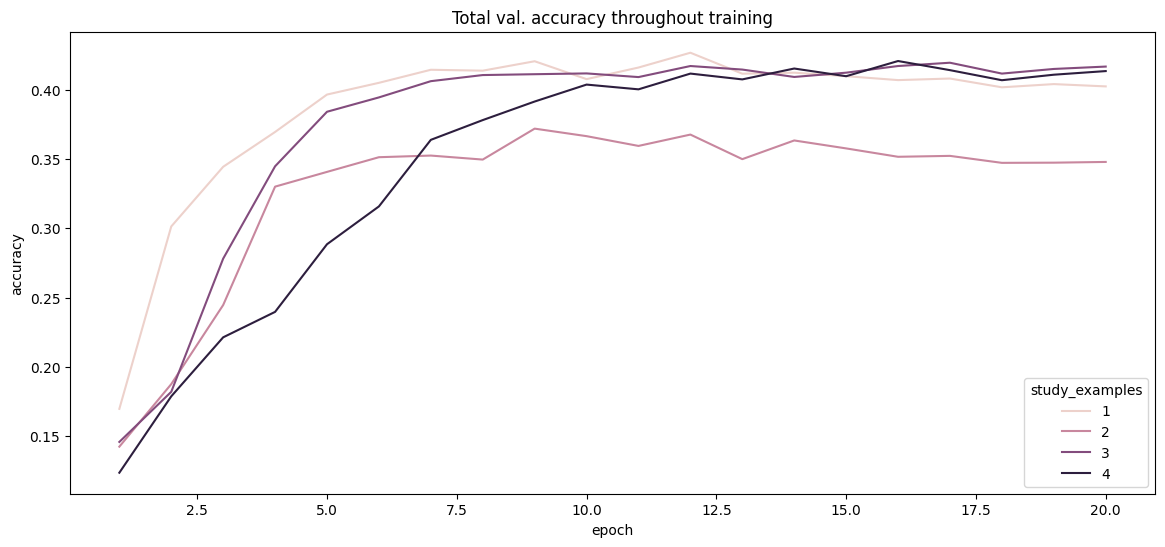

In [24]:
val_acc_by_nstudy_overall = pd.concat([val_acc1,val_acc2,val_acc3,val_acc4])
fig, ax = plt.subplots(figsize=(14,6))
_ = sns.lineplot(data=val_acc_by_nstudy_overall, x="epoch", y="accuracy", hue="study_examples", ax=ax)
_ = ax.legend(title="study_examples", loc="lower right") 
_ = ax.set_title("Total val. accuracy throughout training")